## **Part I - (Ford GoBike Dataset)**

## **by (Abduaziz)**

### Introduction

> Final Project 🎉

Ford GoBike Dataset - regional bike sharing system in the Sna Francisco. The dataset used for this exploratory analysis consists of individual trip data.

#### **📚 Table of Contents**

1. [🔥Preliminary Wrangling](#pre)
2. [✨Univariate Exploration](#u)

   - [📊 Members Age](#u1)
   - [📊 Trip Duration](#u2)
   - [📊 Trip Distribution by day of week](#u3)
   - [📊 Trip Distribution by Day Hours](#u4)
   - [📊 Users Type](#u5)
   - [📊 Members Gender](#u6)

3. [🚀Bivariate Exploration](#biv)
   - [✅ Average Trip duration based on weekdays](#b1)
   - [✅ Users type by Weekdays](#b2)
   - [✅ Member age based & user type](#b3)
   - [🌍 GeoHeatmap of startion station](#b4)
   - [✅ Trip distribution vary between customers and subscribers](#b5)
   - [✅ Trip distribution vary by gender](#b6)
   - [✅ Daily usage by users type](#b7)
4. [💎Multivariate Exploration](#mul)
   - [✅ Hourly Usage Of Bikes vary by weekdays on Subscribers & Customers](#c1)
   - [✅ Durations for bikers](#c2)

## **🔥Preliminary Wrangling**

<a id="pre"></a>


In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.


In [2]:
df:pd.DataFrame = pd.read_csv("201902-fordgobike-tripdata.csv")
df.head(5)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [4]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [5]:
# Try to find sum of nulls
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [6]:
# There are verrry lot null values & we should remove them
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 174952 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             174952 non-null  int64  
 1   start_time               174952 non-null  object 
 2   end_time                 174952 non-null  object 
 3   start_station_id         174952 non-null  float64
 4   start_station_name       174952 non-null  object 
 5   start_station_latitude   174952 non-null  float64
 6   start_station_longitude  174952 non-null  float64
 7   end_station_id           174952 non-null  float64
 8   end_station_name         174952 non-null  object 
 9   end_station_latitude     174952 non-null  float64
 10  end_station_longitude    174952 non-null  float64
 11  bike_id                  174952 non-null  int64  
 12  user_type                174952 non-null  object 
 13  member_birth_year        174952 non-null  float64
 14  memb

In [7]:
# There are no duplicates
df.duplicated().sum()

0

In [8]:
# Create column for member's age
# now - birth_year = age

from datetime import datetime

df["member_age"] =(2019 - df["member_birth_year"]).astype(int) # convert to int
df["member_age"]

0         35
2         47
3         30
4         45
5         60
          ..
183407    23
183408    35
183409    29
183410    31
183411    30
Name: member_age, Length: 174952, dtype: int32

In [9]:
df.head(5)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,35
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,47
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,30
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,45
5,1793,2019-02-28 23:49:58.6320,2019-03-01 00:19:51.7600,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,60


In [10]:
# Birth year is float, lets convert it to int
df["member_birth_year"] = df["member_birth_year"].astype(int)
df.head(5)["member_birth_year"]

0    1984
2    1972
3    1989
4    1974
5    1959
Name: member_birth_year, dtype: int32

In [11]:
# We will removed columns that no longer need

columns: list = [
    "start_station_id", "start_station_name", "end_station_id", "end_station_name",
    "end_station_latitude", "end_station_longitude", "bike_id", "member_birth_year",
    "bike_share_for_all_trip"
]

df = df.drop(columns,axis=1)
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_latitude',
       'start_station_longitude', 'user_type', 'member_gender', 'member_age'],
      dtype='object')

Convert duration to minutes from seconds

`min = sec/60`

In [12]:
df["duration_min"] = (df["duration_sec"]/60).astype(int)
df["duration_min"].describe()

count    174952.000000
mean         11.241461
std          27.371269
min           1.000000
25%           5.000000
50%           8.000000
75%          13.000000
max        1409.000000
Name: duration_min, dtype: float64

### **⚙ What is the structure of your dataset?**

There are 16 types of columns.

- Information about trip (its duration ...):

  - `duration_sec`
  - `start_time`
  - `end_time`

- Information about stations (start/end) (its cords, name and id):

  - `station_id`
  - `station_name`
  - `station_latitude`
  - `station_longitude`

- Customer data:
  - `bike_id`
  - `user_type`
  - `member_birth_year`
  - `member_gender`
  - `bike_share_for_all_trip`

### **✨What is/are the main feature(s) of interest in your dataset?**

- Cords of stations are interesting for me (I want to visualize them)
- Duration of biking time
- Members age
- Users type, I want to compare them

### **🎈What features in the dataset do you think will help support your investigation into your feature(s) of interest?**
* Cords of stations
* Customers data ( birth year, gender and so on )
* Starting and ending time. I think, I can extract some interesting information about a day (weekday, hours ... )

## **✨ Univariate Exploration**

<a id="u"></a>

In [13]:
# Change figure size
sb.set(rc={'figure.figsize':(11.7,8.27)})

In [14]:
# simple shortcut function for saving plot images

def save_plot(name:str)->None:
    plt.savefig("plots/"+name)
    return

### **📊 Members Age**
<a id="u1"></a>

In [15]:
df["member_age"].describe()

count    174952.000000
mean         34.196865
std          10.118731
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max         141.000000
Name: member_age, dtype: float64

WoW 141 😂 (record!)

In [16]:
df[df["member_age"]>=100].count()

duration_sec               72
start_time                 72
end_time                   72
start_station_latitude     72
start_station_longitude    72
user_type                  72
member_gender              72
member_age                 72
duration_min               72
dtype: int64

In [17]:
# Keep columns with member age below 70
df = df[df["member_age"]<=70]
df["member_age"].describe()


count    174377.000000
mean         34.038876
std           9.714521
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max          70.000000
Name: member_age, dtype: float64

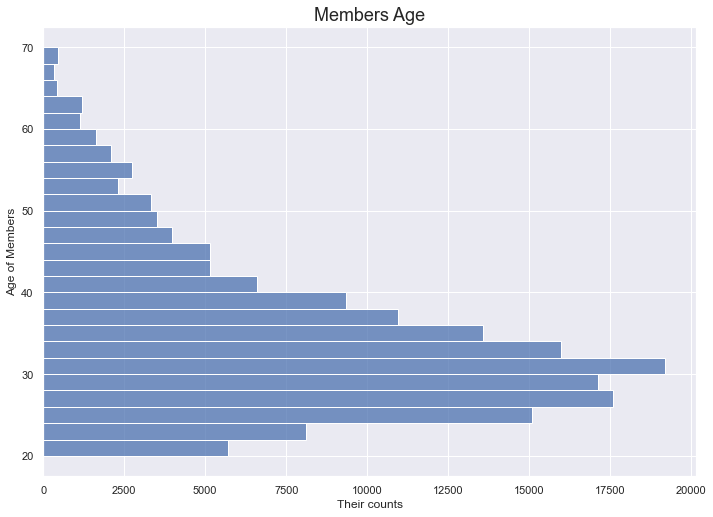

In [18]:
BIN_SIZE:int = 2
bins = np.arange(20,df["member_age"].max()+BIN_SIZE,BIN_SIZE)
plt.ylabel("Age of Members"),plt.xlabel("Their counts"),plt.title("Members Age",fontsize=18)

sb.histplot(df,y="member_age",bins=bins)
save_plot("member_age")

In [19]:
df["member_age"].value_counts()

31    10214
26     9323
30     8967
29     8640
28     8484
27     8245
32     8010
33     7953
25     7654
24     7420
34     7023
35     6557
36     5953
39     5011
37     4987
23     4637
38     4344
40     3756
22     3476
21     3208
41     2830
42     2706
45     2633
20     2504
44     2503
43     2435
46     2080
51     1927
48     1924
47     1909
19     1675
49     1590
54     1546
50     1414
52     1315
55     1189
56     1151
53      989
57      955
58      821
62      807
59      806
60      624
61      517
63      392
65      301
67      189
68      180
69      178
66      158
64      134
70       99
18       34
Name: member_age, dtype: int64

It looks very good! As you can see there are many members that 33 old (they are almost 10.5k)

### **📊 Trip Duration**

<a id="u2"></a>

<AxesSubplot:title={'center':'Trip Duration'}, xlabel='Their counts', ylabel='Duration (min)'>

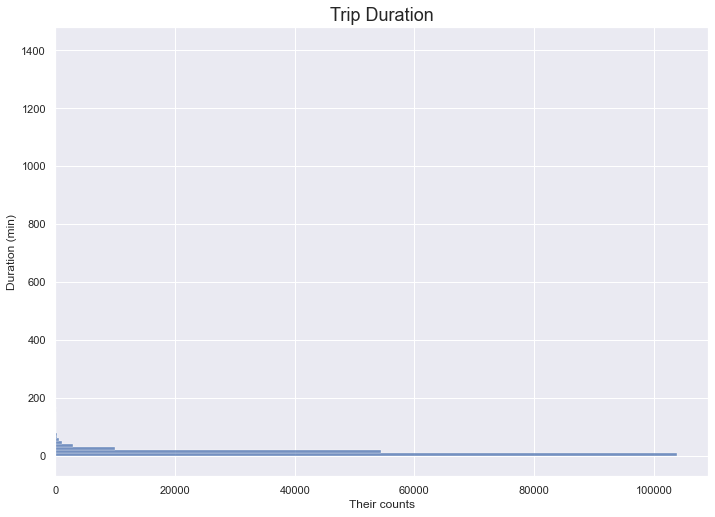

In [20]:
BIN_SIZE: int = 10
bins = np.arange(0, df["duration_min"].max() + BIN_SIZE, BIN_SIZE)
plt.ylabel("Duration (min)"), plt.xlabel(
    "Their counts"), plt.title("Trip Duration", fontsize=18)
sb.histplot(df, y="duration_min", bins=bins)


I'm going to zoom in to most cases for a closer picture of what the distribution is like.

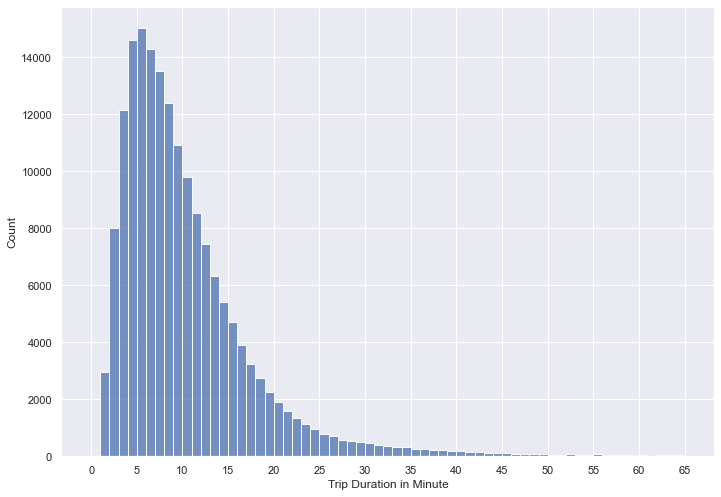

In [21]:
bins,ticks = np.arange(0, 66, 1),np.arange(0, 66, 5)

plt.xticks(ticks, ticks)
plt.xlabel('Trip Duration in Minute')
sb.histplot(data=df,x="duration_min",bins=bins)
save_plot("duration_min")

Almost all trips were less than 60 min and most of them were between 1 to 20 minutes range.

### **📊 Trip Distribution by day of week**

<a id="u3"></a>

Extracting useful data from start time

In [22]:
df["start_time"] = pd.to_datetime(df["start_time"])
df["start_hour_of_day"] = df["start_time"].dt.strftime('%H')
df["start_day_of_week"] = df["start_time"].dt.strftime('%A')
df["start_month"] = df["start_time"].dt.strftime('%B')

In [23]:
df["start_day_of_week"].sample(3)

88780     Saturday
42980       Friday
176702    Saturday
Name: start_day_of_week, dtype: object

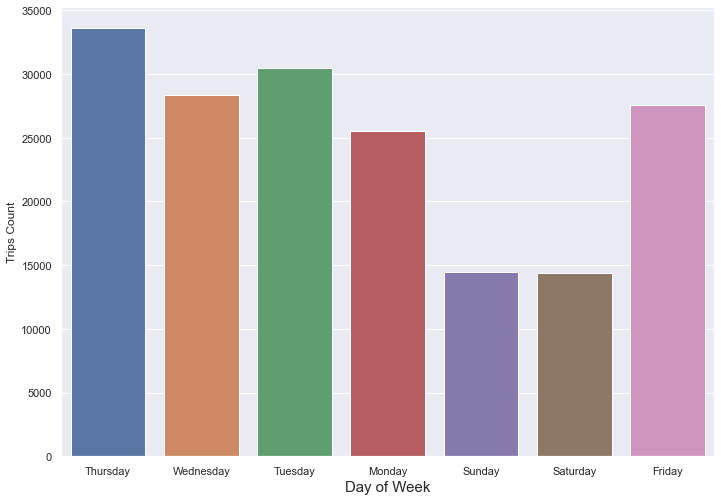

In [24]:
sb.countplot(data=df, x="start_day_of_week")
plt.xlabel('Day of Week',fontsize=15),plt.ylabel('Trips Count')
save_plot("day_of_week")

Thursday is the peak day of the week which have most bikers

### **📊 Trip Distribution by Day Hours**

<a id="u4"></a>

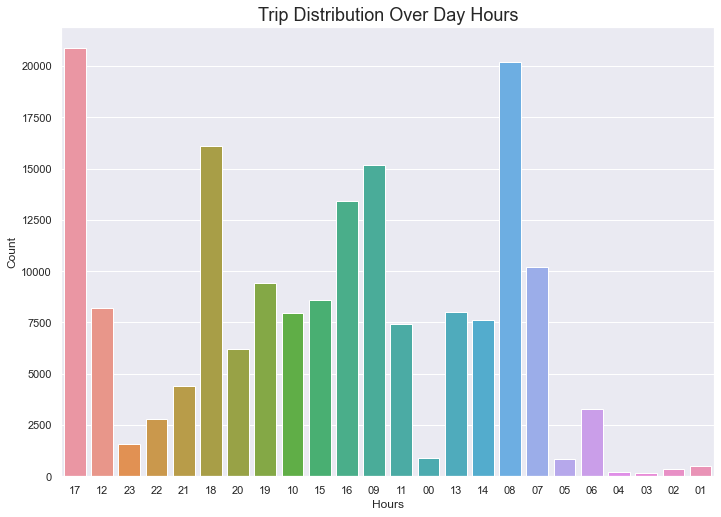

In [25]:
plt.title("Trip Distribution Over Day Hours",fontsize=18)
sb.countplot(data=df,x="start_hour_of_day")
plt.xlabel("Hours"),plt.ylabel("Count")
save_plot("trip_dist")

The most of trips started at 5:00 PM,6:00 PM and 8:00 AM

### **📊 Users Type**

<a id="u5"></a>

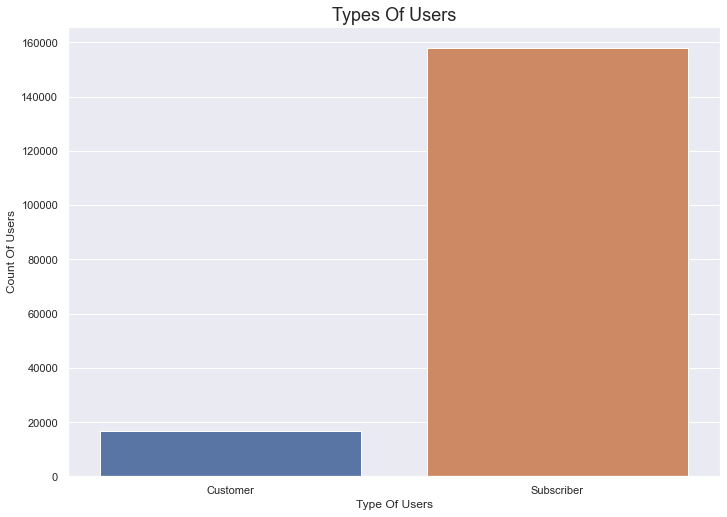

In [26]:
sb.countplot(data=df,x="user_type")
plt.title("Types Of Users",fontsize=18)
plt.ylabel("Count Of Users"),plt.xlabel("Type Of Users")
save_plot("users_type")

The number of subscribers many than customers almost by 87%

### **📊 Members Gender**

<a id="u6"></a>

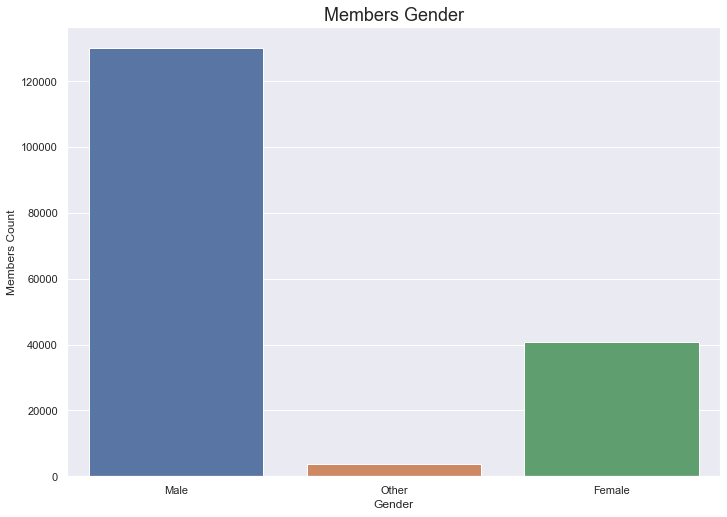

In [27]:
sb.countplot(data=df,x="member_gender")
plt.title("Members Gender",fontsize=18)
plt.ylabel("Members Count"),plt.xlabel("Gender")
save_plot("member_gender")

Male users are more than Female users

* Most of trips so quick and they were around only 5 and 15 min.
* Male riders are more active than females
* The most of riders were subscribers
* The most of trips were in 5:00 PM & Thursdays
* And they were around 30 to 40 years old.

## **🚀Bivariate Exploration**

<a id="biv"></a>

### **✅ Average Trip duration based on weekdays**
<a id="b1"></a>

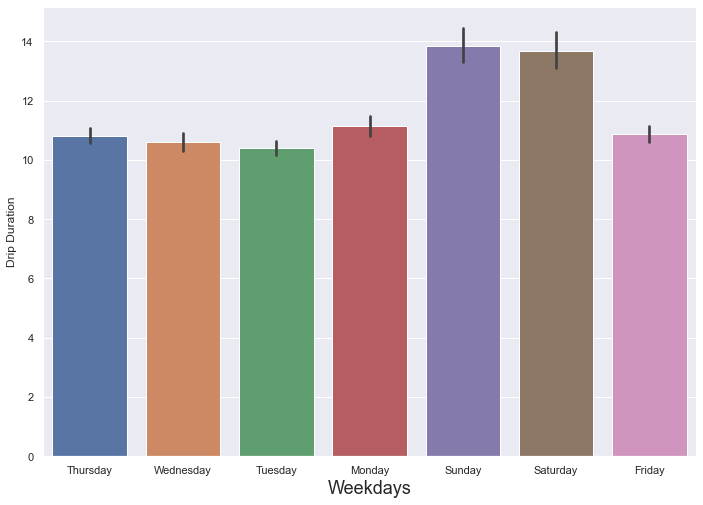

In [28]:
sb.barplot(data=df,y="duration_min",x="start_day_of_week")
plt.xlabel("Weekdays",fontsize=18),plt.ylabel("Drip Duration")
save_plot("avg_trip_duration")

Trip durations are much shorter on Tuesday compared to Sunday and Saturday.

### **✅ Users type by Weekdays**
<a id="b2"></a>

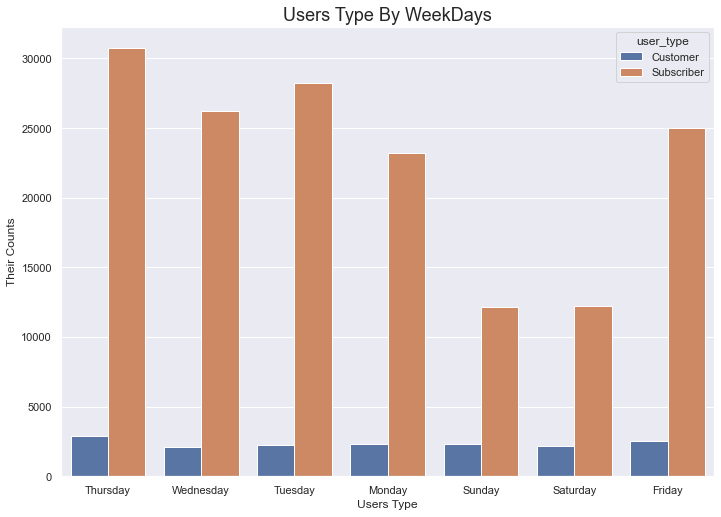

In [29]:
sb.countplot(data=df,x="start_day_of_week",hue="user_type")
plt.xlabel("Users Type"),plt.ylabel("Their Counts")
plt.title("Users Type By WeekDays",fontsize=18)
save_plot("user_type_weekday")

There is no doubt that the number of subscribers is more than customers. Decreasing the number of subscribers on weekends shows us that they ride bikes only during workdays 💼

### **✅ Member age based & user type**
<a id="b3"></a>

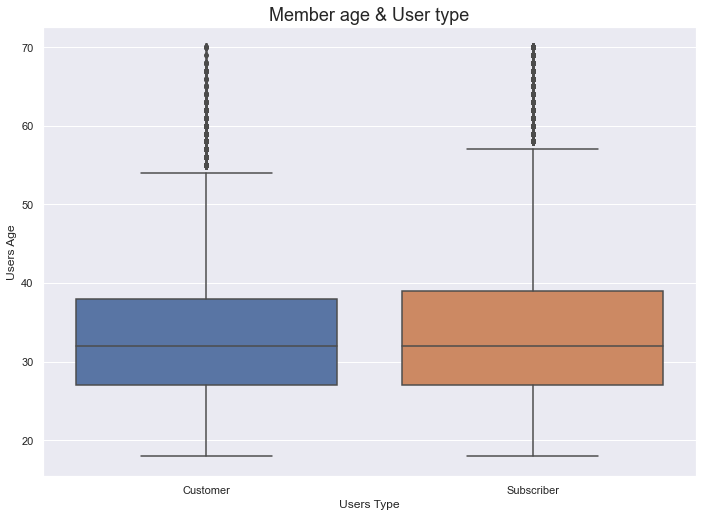

In [30]:
sb.boxplot(data=df,x="user_type",y="member_age")
plt.title("Member age & User type",fontsize=18)
plt.xlabel("Users Type"),plt.ylabel("Users Age")
save_plot("member_age_user_type")

The age of subscribers is slightly older than customer users.

### **🌍 GeoHeatmap of startion station**
<a id="b4"></a>

In [31]:
# Required imports
# You should "trust" to this notebook from FILE panel on your local computer
from folium import Map
from folium.plugins import HeatMap

We can calculate approximate location of trips by stations cord's mean

In [32]:
lat,long = df['start_station_latitude'].mean() , df['start_station_longitude'].mean()

Let's see the location where trips are going

In [33]:
map = Map([lat,long],zoom_start=12)
map

Heatmap of start stations:

In [34]:
map = Map([lat,long],zoom_start=12)

cords: list = df[
    ['start_station_latitude',
     'start_station_longitude']
].values.tolist()

map.add_child(HeatMap(cords))

map

We can see that in Oakland, Berkeley and the centre of San Francisco (and near san Francisco's port) were many start stations. But in the below map you can see, there is also another region that was many trips despite its area (San Jose & Japantown).

### **✅ Trip distribution vary between customers and subscribers**
<a id="b5"></a>

In [35]:
duration_data = df[df["duration_min"]<=70] # by doing this we achieve zoom

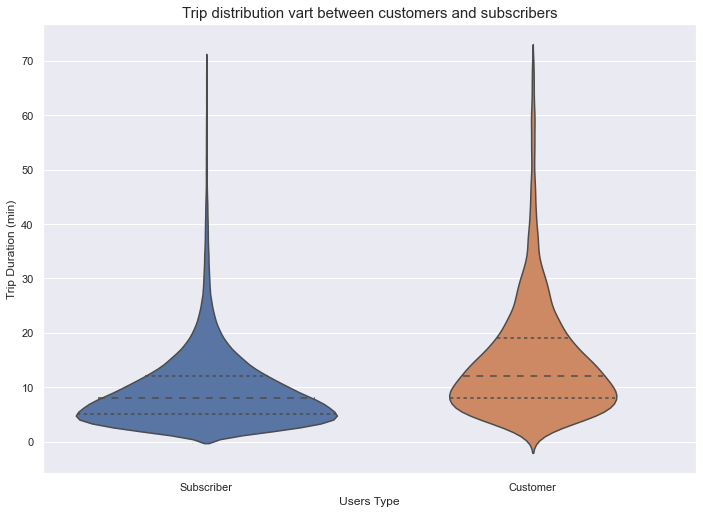

In [36]:
sb.violinplot(data=duration_data,x="user_type",y="duration_min",inner="quartile")
plt.title("Trip distribution vart between customers and subscribers",fontsize=15)
plt.xlabel("Users Type"),plt.ylabel("Trip Duration (min)")
save_plot("dist_vary_customers_subscribers")

You can see duration is too much narrower on customers than subscribers. Subscribers have a exact goal of riding bikes compared with customers. Because customers rented bikes longer than subscribers.

### **✅ Trip distribution vary by gender**
<a id="b6"></a>

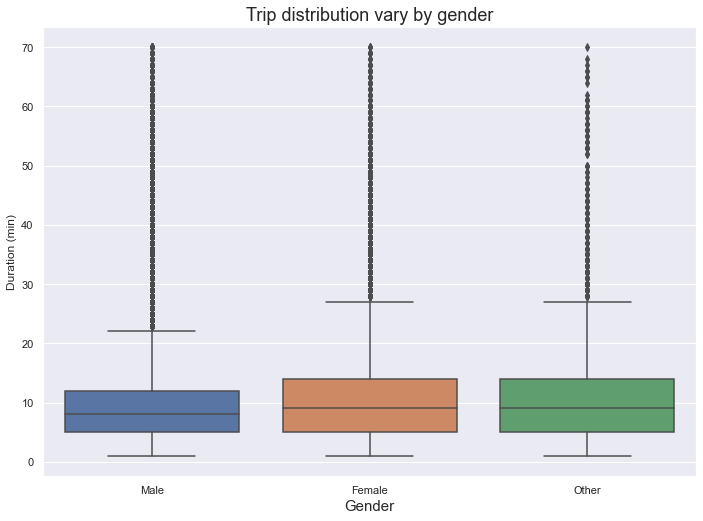

In [37]:
trips_df = df[df["duration_min"]<=70] # by doing this we achieve zoom
sb.boxplot(data=trips_df,x="member_gender",y="duration_min")
plt.title("Trip distribution vary by gender",fontsize=18)
plt.xlabel("Gender",fontsize=15),plt.ylabel("Duration (min)")
save_plot("dist_vary_by_gender")

In my view, there are not too many differences. But we can say those male riders tend to have shorter trips than females.

### **✅ Daily usage by users type**
<a id="b7"></a>

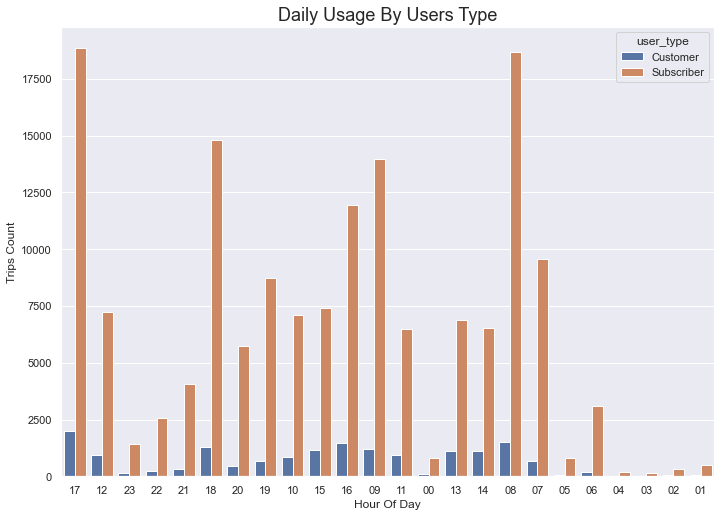

In [38]:
sb.countplot(data=df,x="start_hour_of_day",hue="user_type")
plt.title("Daily Usage By Users Type",fontsize=18)
plt.xlabel("Hour Of Day"),plt.ylabel("Trips Count")
save_plot("daily_usage_user_type")

Subscribers are always at peak! Most part of the customers & subscribers rides in the afternoon. But between 1:00 and 5:00 AM, there were not any customer bikers.

#### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

* Oakland, Berkeley and the centre of San Francisco (and near san Francisco's port) were many start stations. But in the below map you can see, there is also another region that was many trips despite its area (San Jose & Japantown).
* The usage of subscribers more than customers!
* We can see Customers are using bike-sharing systems very different from subscribers. I think they use the system only for leisure purposes (according to their trip duration).
* 5:00 PM has the most bikers


#### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?
* Subscribers take much quicker rides
* Subscribers older than customers
* Most Subscribers and Customer bikers are male.

## **💎Multivariate Exploration**

<a id="mul"></a>

### **✅ Hourly Usage Of Bikes vary by weekdays on Subscribers & Customers**
<a id="c1"></a>

In [39]:
def make_counts(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Simple function for calculating counts
    It may help to avoit repetitive code :)
    """
    counts = dataframe.groupby(
        ['start_day_of_week', 'start_hour_of_day']
    ).size().reset_index(name='count')

    return counts.pivot(
        index='start_day_of_week',
        columns='start_hour_of_day',
        values='count'
    )


def set_labels(_for: str) -> None:
    plt.suptitle('Hourly usage during weekdays', fontsize=18)
    plt.title(_for,loc="left",fontsize=15), plt.xlabel('Hour of Day'), plt.ylabel('Day of Week')
    return


In [40]:
# Fetch customers and subscribers data from DF by filtering user type field
customers,subscribers = df[df["user_type"] == "Customer"],df[df["user_type"] == "Subscriber"]

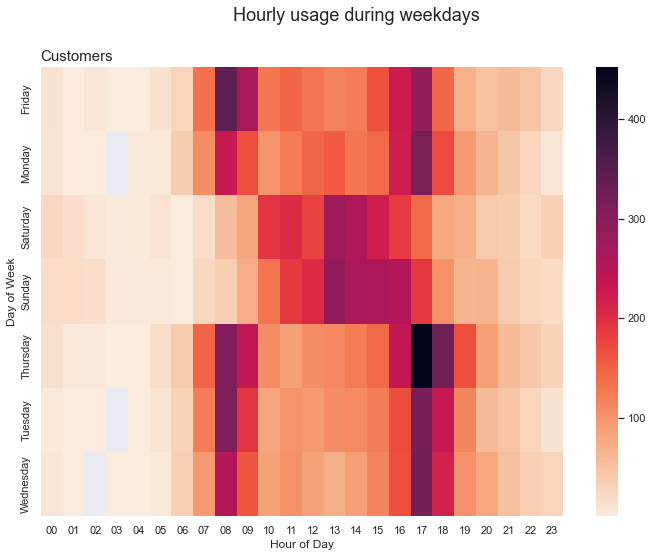

In [41]:
sb.heatmap(make_counts(customers), cmap='rocket_r')
set_labels("Customers")
save_plot("hourly_usage_vary_cust")

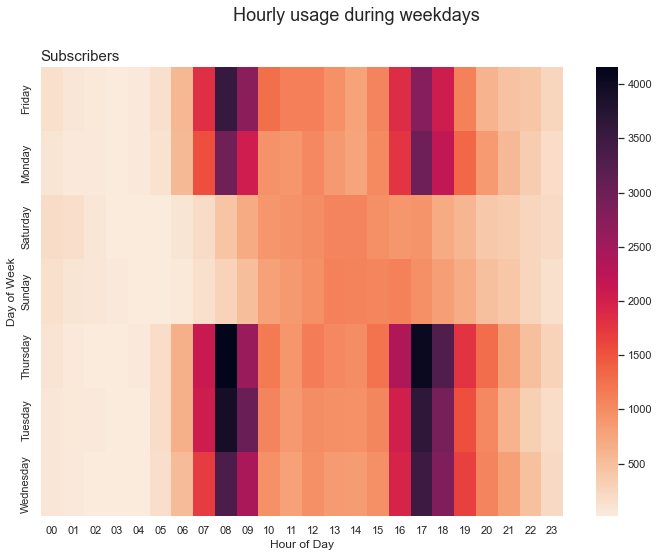

In [42]:

sb.heatmap(make_counts(subscribers), cmap='rocket_r')
set_labels("Subscribers")
save_plot("hourly_usage_vary_subs")

These heat maps show very different patterns of two types of users. It is clear that subscribers don't ride mostly on weekends and they use this system only on their workdays (from Monday to Friday). So, many trips were in the range of 7-9 AM & 17-18 PM (workdays).

### **✅ Durations for bikers**
<a id="c2"></a>

Text(0.5, 1.0, 'Durations for bikers who are older than 50 years old')

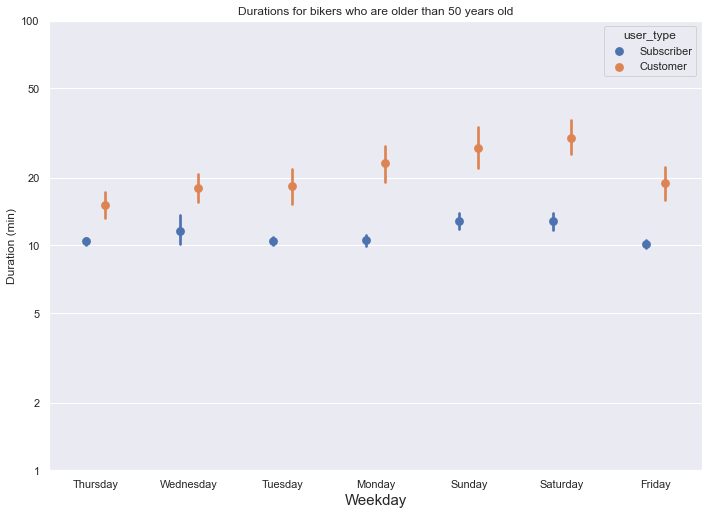

In [43]:
ticks = [1, 2, 5, 10, 20, 50, 100]
users_data: pd.DataFrame = df[df["member_age"] >= 50]

ax = sb.pointplot(
    data=users_data,
    x='start_day_of_week',
    y='duration_min',
    hue='user_type',
    dodge=0.2,
    linestyles=''
)
plt.yscale('log')
plt.ylabel('Duration (min)'),plt.xlabel("Weekday",fontsize=15)
plt.yticks(ticks, ticks)
plt.title('Durations for bikers who are older than 50 years old')


We can see that "Customer" bikers absolutely ride longer than "Subscribers"

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

* The short period of a ride for "Subscribers" corresponds to their high concentration on bike durations Monday through Friday


### Were there any interesting or surprising interactions between features?
* On sunday & saturday the duration trips are longer compared with other weekdays.
* "Customers" ride longer on average compared to "Subscribers".

In [44]:
df.to_csv("fordgobike_clean.csv")